# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [26]:
#! pip install mne

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load Data

In [ ]:
CONDITION  = "BLA"
SUBJECT_ID = 6
CHANNELS   = "BLA"   # T7, T8, TP7, TP8

# Data path (resolved inside utils): <project>/dataset/BLA/binepochs filtered ICArej BLAAvgBOS5.set
epochs = load_eeg_data(CONDITION, SUBJECT_ID, channels=CHANNELS)

data   = epochs.get_data()   # (n_trials, n_channels, n_times)  — in Volts (MNE default)
data   = data * 1e6           # convert to µV
times  = epochs.times        # in seconds
ch_names = epochs.ch_names
sfreq  = epochs.info['sfreq']

n_trials, n_channels, n_times = data.shape

print(f"Condition     : {CONDITION}  |  Subject: {SUBJECT_ID}")
print(f"Channels      : {ch_names}")
print(f"Trials        : {n_trials}")
print(f"Time window   : {times[0]*1000:.0f} ms  to  {times[-1]*1000:.0f} ms")
print(f"Sampling rate : {sfreq} Hz")
print(f"Data shape    : {data.shape}  (trials × channels × times)")

/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Condition     : BLA  |  Subject: 5
Channels      : ['T7', 'T8', 'TP7', 'TP8']
Trials        : 60
Time window   : -500 ms  to  2998 ms
Sampling rate : 512.0 Hz
Data shape    : (60, 4, 1792)  (trials × channels × times)


## 2. Baseline Correction  (−200 ms to 0 ms, mean subtraction)

In [14]:
BASELINE_TMIN = -0.200   # seconds
BASELINE_TMAX =  0.000

baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
print(f"Baseline samples : {baseline_mask.sum()}  "
      f"({times[baseline_mask][0]*1000:.0f} ms to {times[baseline_mask][-1]*1000:.0f} ms)")

# Mean per trial × channel over the baseline window
baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (trials, channels, 1)
baseline_std = data[:, :, baseline_mask].std(axis=-1, keepdims=True)

# Subtract from every time point
data_bc = (data - baseline_mean) / baseline_std   # (trials, channels, times)

print("Baseline correction done — data_bc shape:", data_bc.shape)
grand_avg_auditory = np.nanmean(data_bc, axis=0)   # (channels, T)
grand_avg_auditory = np.nanmean(grand_avg_auditory, axis=0) # (T,)

Baseline samples : 103  (-199 ms to 0 ms)
Baseline correction done — data_bc shape: (60, 4, 1792)


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_peak_in_window(time_ms, signal, window_ms, polarity="pos"):
    """
    在给定时间窗内找 peak / trough

    Parameters
    ----------
    time_ms : array-like, shape [T]
    signal : array-like, shape [T]
    window_ms : [start_ms, end_ms]
    polarity : {"pos", "neg"}
        pos: 找最大值
        neg: 找最小值

    Returns
    -------
    out : dict
        {
            "peak_idx": int or None,
            "peak_time_ms": float or np.nan,
            "peak_amp": float or np.nan,
            "search_start_ms": float,
            "search_end_ms": float,
            "polarity": str,
        }
    """
    time_ms = np.asarray(time_ms, dtype=float)
    signal = np.asarray(signal, dtype=float)

    start_ms, end_ms = window_ms
    mask = (time_ms >= start_ms) & (time_ms <= end_ms)

    if not np.any(mask):
        return {
            "peak_idx": None,
            "peak_time_ms": np.nan,
            "peak_amp": np.nan,
            "search_start_ms": start_ms,
            "search_end_ms": end_ms,
            "polarity": polarity,
        }

    idx_local = np.where(mask)[0]
    seg = signal[idx_local]

    if polarity == "pos":
        best_local = np.nanargmax(seg)
    elif polarity == "neg":
        best_local = np.nanargmin(seg)
    else:
        raise ValueError("polarity must be 'pos' or 'neg'")

    peak_idx = idx_local[best_local]

    return {
        "peak_idx": int(peak_idx),
        "peak_time_ms": float(time_ms[peak_idx]),
        "peak_amp": float(signal[peak_idx]),
        "search_start_ms": float(start_ms),
        "search_end_ms": float(end_ms),
        "polarity": polarity,
    }


def _default_half_width_ms(peak_time_ms):
    """
    根据 peak latency 自动决定最终窗半宽
    """
    if peak_time_ms < 120:
        return 15.0
    elif peak_time_ms < 250:
        return 25.0
    else:
        return 40.0


def build_final_window_from_peak(
    peak_time_ms,
    half_width_ms=None,
    min_time_ms=None,
    max_time_ms=None,
):
    """
    由 peak time 生成最终分析窗
    """
    if np.isnan(peak_time_ms):
        return [np.nan, np.nan]

    if half_width_ms is None:
        half_width_ms = _default_half_width_ms(peak_time_ms)

    tw = [peak_time_ms - half_width_ms, peak_time_ms + half_width_ms]

    if min_time_ms is not None:
        tw[0] = max(tw[0], min_time_ms)
    if max_time_ms is not None:
        tw[1] = min(tw[1], max_time_ms)

    return [float(tw[0]), float(tw[1])]


def detect_erp_windows_from_grand_avg(
    time_ms,
    grand_avg,
    search_windows,
    polarity_map=None,
    half_width_map=None,
    min_time_ms=None,
    max_time_ms=None,
):
    """
    在 grand average 上自动检测 ERP 成分，并生成最终时间窗

    Parameters
    ----------
    time_ms : array-like, shape [T]
    grand_avg : array-like, shape [T]
    search_windows : dict
        例如:
        {
            "P50": [30, 80],
            "N1": [70, 140],
            "P2": [130, 220],
            "N2": [180, 300],
            "P3": [250, 450],
        }

    polarity_map : dict or None
        例如:
        {
            "P50": "pos",
            "N1": "neg",
            "P2": "pos",
            "N2": "neg",
            "P3": "pos",
        }
        如果不提供，默认全是 "pos"

    half_width_map : dict or None
        每个成分最终窗半宽（ms）
        例如:
        {
            "P50": 12,
            "N1": 15,
            "P2": 20,
            "N2": 25,
            "P3": 40,
        }
        不提供则自动按 peak latency 决定

    Returns
    -------
    res_df : pd.DataFrame
        index 为 component name
        columns:
            peak_idx
            peak_time_ms
            peak_amp
            search_start_ms
            search_end_ms
            polarity
            final_start_ms
            final_end_ms
            final_half_width_ms
    """
    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)

    if polarity_map is None:
        polarity_map = {k: "pos" for k in search_windows}

    rows = []
    for comp, tw in search_windows.items():
        polarity = polarity_map.get(comp, "pos")

        peak_info = _find_peak_in_window(
            time_ms=time_ms,
            signal=grand_avg,
            window_ms=tw,
            polarity=polarity,
        )

        peak_time = peak_info["peak_time_ms"]

        if half_width_map is not None and comp in half_width_map:
            half_width = float(half_width_map[comp])
        else:
            half_width = _default_half_width_ms(peak_time) if not np.isnan(peak_time) else np.nan

        final_tw = build_final_window_from_peak(
            peak_time_ms=peak_time,
            half_width_ms=half_width if not np.isnan(half_width) else None,
            min_time_ms=min_time_ms,
            max_time_ms=max_time_ms,
        )

        row = {
            "component": comp,
            **peak_info,
            "final_start_ms": final_tw[0],
            "final_end_ms": final_tw[1],
            "final_half_width_ms": half_width,
        }
        rows.append(row)

    res_df = pd.DataFrame(rows).set_index("component")
    return res_df


def plot_grand_avg_with_windows(
    time_ms,
    grand_avg,
    res_df,
    title="Grand Average ERP with Detected Windows",
    figsize=(10, 5),
):
    """
    画 grand average，并标注 peak 和 final windows
    """
    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)

    plt.figure(figsize=figsize)
    plt.plot(time_ms, grand_avg, linewidth=2, label="grand avg")
    plt.axvline(0, linestyle="--", alpha=0.6)

    y_min = np.nanmin(grand_avg)
    y_max = np.nanmax(grand_avg)
    y_span = y_max - y_min if y_max > y_min else 1.0

    for comp, row in res_df.iterrows():
        fs = row["final_start_ms"]
        fe = row["final_end_ms"]
        pt = row["peak_time_ms"]
        pa = row["peak_amp"]

        if not np.isnan(fs) and not np.isnan(fe):
            plt.axvspan(fs, fe, alpha=0.15)

        if not np.isnan(pt) and not np.isnan(pa):
            plt.scatter([pt], [pa], s=60)
            plt.text(
                pt,
                pa + 0.03 * y_span,
                f"{comp}\n{pt:.1f} ms",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [19]:
auditory_search = {
    "P50": [30, 80],
    "N1":  [70, 140],
    "P2":  [130, 220],
    "N2":  [180, 300],
    "P3":  [250, 450],
}

auditory_polarity = {
    "P50": "pos",
    "N1":  "neg",
    "P2":  "pos",
    "N2":  "neg",
    "P3":  "pos",
}

tactile_search = {
    "P50": [20, 70],
    "N1":  [50, 120],
    "P2":  [100, 200],
    "N2":  [130, 260],
    "P3":  [220, 420],
}

tactile_polarity = {
    "P50": "pos",
    "N1":  "neg",
    "P2":  "pos",
    "N2":  "neg",
    "P3":  "pos",
}

half_width_map= {
    "P50": 15,
    "N1":  25,
    "P2":  25,
    "N2":  25,
    "P3":  50,
}

           peak_idx  peak_time_ms  peak_amp  search_start_ms  search_end_ms  \
component                                                                     
P50             294     74.218750  0.945650             30.0           80.0   
N1              326    136.718750 -0.249838             70.0          140.0   
P2              323    130.859375 -0.179375            130.0          220.0   
N2              361    205.078125 -0.489665            180.0          300.0   
P3              459    396.484375  0.585946            250.0          450.0   

          polarity  final_start_ms  final_end_ms  final_half_width_ms  
component                                                              
P50            pos       59.218750     89.218750                 15.0  
N1             neg      111.718750    161.718750                 25.0  
P2             pos      105.859375    155.859375                 25.0  
N2             neg      180.078125    230.078125                 25.0  
P3            

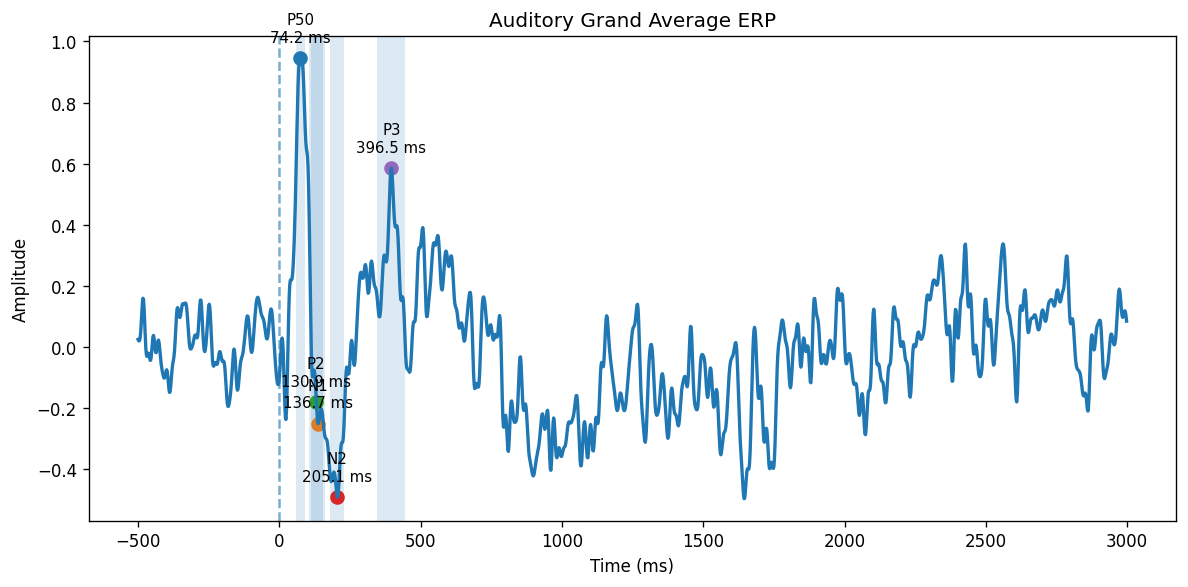

In [20]:
time_ms = times*1000
res_aud = detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg_auditory,
    search_windows=auditory_search,
    polarity_map=auditory_polarity,
    half_width_map=half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

print(res_aud)
plot_grand_avg_with_windows(
    time_ms=time_ms,
    grand_avg=grand_avg_auditory,
    res_df=res_aud,
    title="Auditory Grand Average ERP",
)

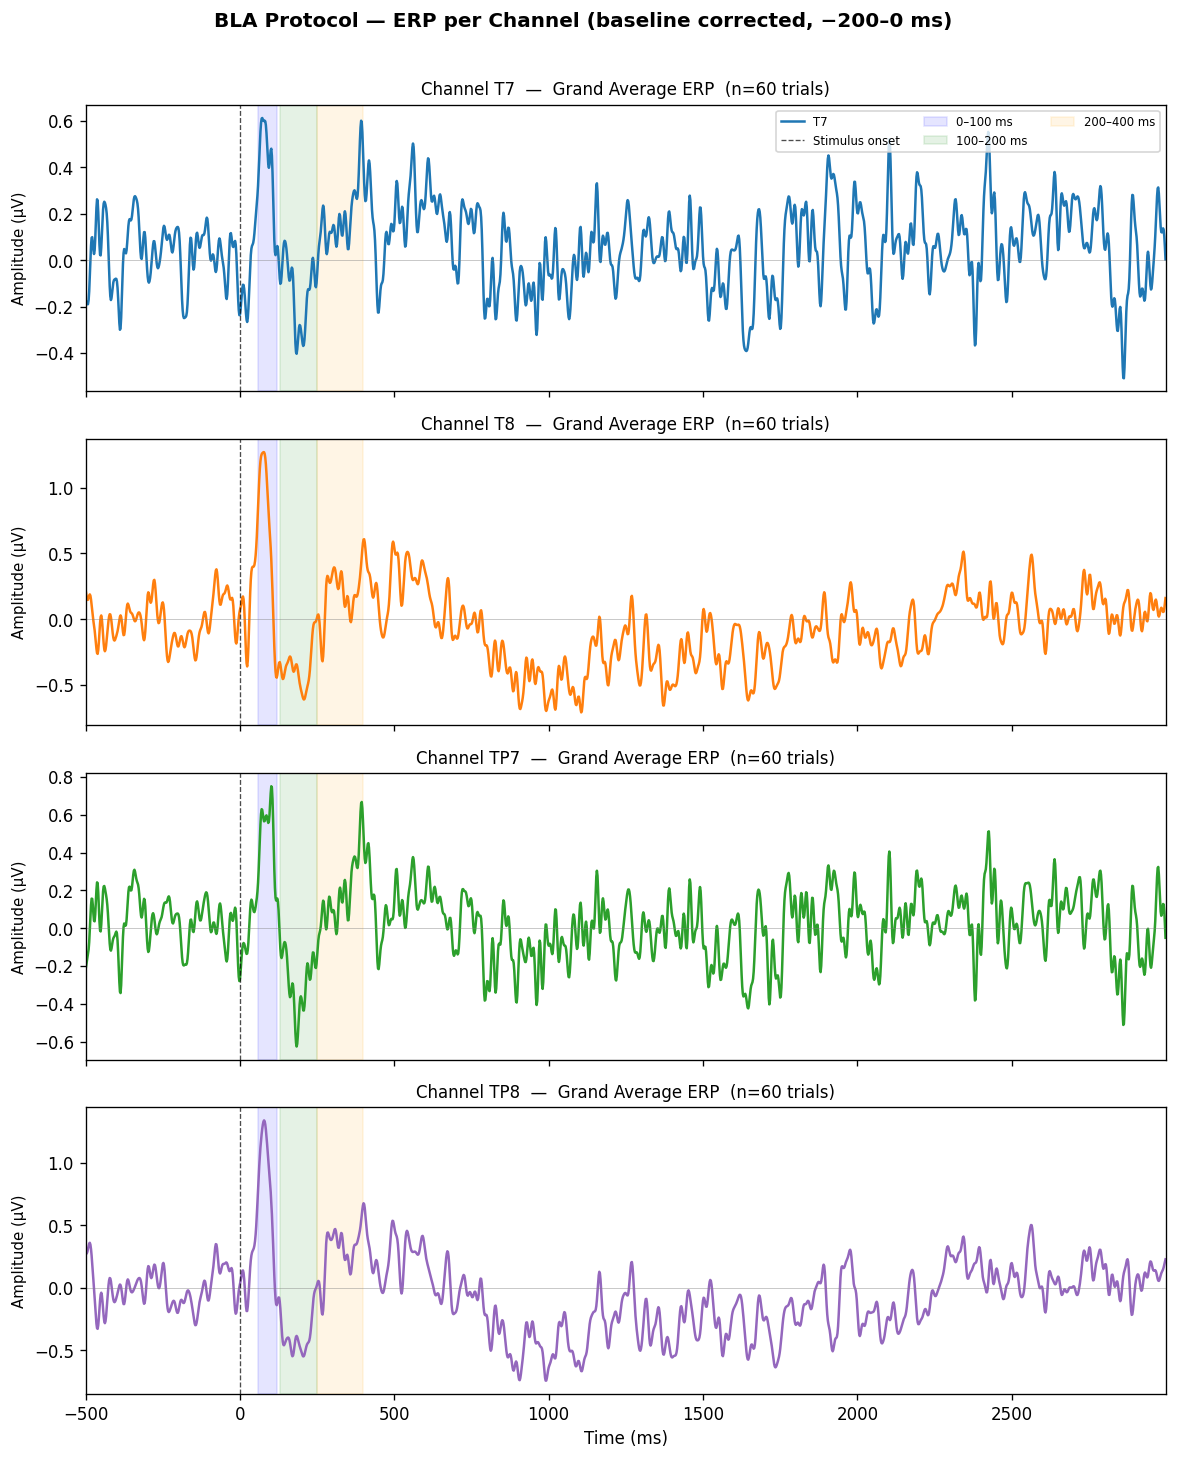

Figure saved: erp_BLA_per_channel.png


In [8]:
erp = data_bc.mean(axis=0)   # (n_channels, n_times)  — grand average ERP
times_ms = times * 1000      # convert to ms for plotting

fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)
if n_channels == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.4, n_channels))

for i, (ax, ch) in enumerate(zip(axes, ch_names)):
    ax.plot(times_ms, erp[i], color=colors[i], linewidth=1.5, label=ch)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7, label='Stimulus onset')
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Shade feature windows
    ax.axvspan(60, 120,   alpha=0.10, color='blue',   label='0–100 ms')
    ax.axvspan(130, 250, alpha=0.10, color='green',  label='100–200 ms')
    ax.axvspan(250, 400, alpha=0.10, color='orange', label='200–400 ms')

    ax.set_ylabel('Amplitude (µV)', fontsize=9)
    ax.set_title(f'Channel {ch}  —  Grand Average ERP  (n={n_trials} trials)', fontsize=10)
    ax.set_xlim(times_ms[0], times_ms[-1])

    if i == 0:
        ax.legend(loc='upper right', fontsize=7, ncol=3)

axes[-1].set_xlabel('Time (ms)', fontsize=10)
fig.suptitle(f'BLA Protocol — ERP per Channel (baseline corrected, −200–0 ms)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('erp_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: erp_BLA_per_channel.png")

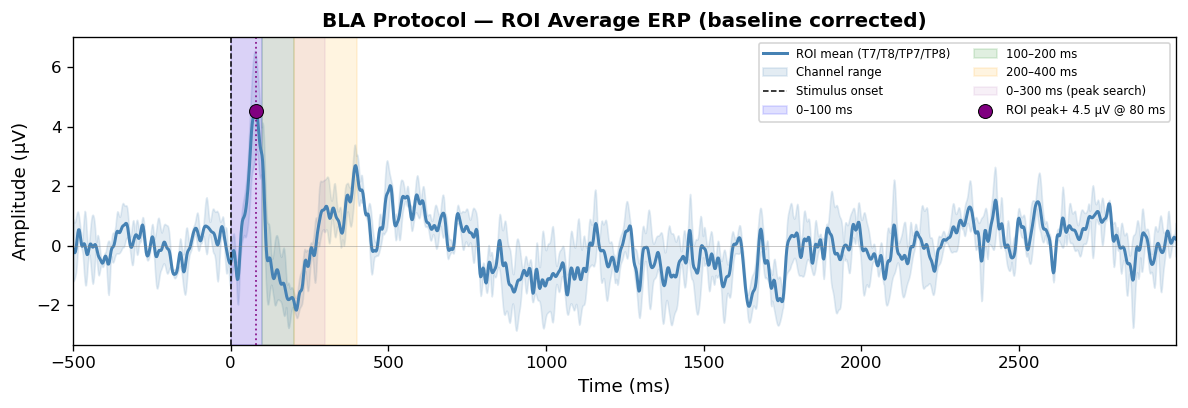

In [31]:
# --- ROI average ERP (mean across all BLA channels) ---
erp_roi = erp.mean(axis=0)   # (n_times,)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(times_ms, erp_roi, color='steelblue', linewidth=1.8, label='ROI mean (T7/T8/TP7/TP8)')
ax.fill_between(times_ms, erp.min(axis=0), erp.max(axis=0),
                color='steelblue', alpha=0.15, label='Channel range')
ax.axvline(0, color='k', linestyle='--', linewidth=0.9, label='Stimulus onset')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvspan(0, 100,   alpha=0.12, color='blue',   label='0–100 ms')
ax.axvspan(100, 200, alpha=0.12, color='green',  label='100–200 ms')
ax.axvspan(200, 400, alpha=0.12, color='orange', label='200–400 ms')
ax.axvspan(0, 300, alpha=0.06, color='purple', label='0–300 ms (peak search)')

# Grand-average ROI: peak positive & latency in 0–300 ms (same definition as trial features)
_pk_mask = (times_ms >= 0) & (times_ms <= 300)
_t = times_ms[_pk_mask]
_v = erp_roi[_pk_mask]
_i = int(np.argmax(_v))
_lat, _amp = _t[_i], _v[_i]
ax.scatter([_lat], [_amp], color='purple', s=70, zorder=6, edgecolors='k', linewidths=0.6,
           label=f'ROI peak+ {_amp:.1f} µV @ {_lat:.0f} ms')
ax.axvline(_lat, color='purple', linestyle=':', linewidth=1.1, alpha=0.85)

ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Amplitude (µV)', fontsize=11)
ax.set_title('BLA Protocol — ROI Average ERP (baseline corrected)', fontsize=12, fontweight='bold')
ax.set_xlim(times_ms[0], times_ms[-1])
ax.legend(loc='upper right', fontsize=7, ncol=2)
fig.tight_layout()
plt.savefig('erp_BLA_roi_average.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [ ]:
import numpy as np
import pandas as pd

# =========================
# 1) read time_wind
# =========================

component_windows = {
    comp: {
        "tmin_s": row["final_start_ms"] / 1000.0,
        "tmax_s": row["final_end_ms"] / 1000.0,
        "polarity": row["polarity"],
    }
    for comp, row in res_aud.iterrows()
}

print("Detected windows from res_aud:")
for comp, info in component_windows.items():
    print(
        f"  {comp}: {info['tmin_s']*1000:.1f}–{info['tmax_s']*1000:.1f} ms "
        f"(polarity={info['polarity']})"
    )


# =========================
# 2) window mask
# =========================
window_masks = {}
for comp, info in component_windows.items():
    mask = (times >= info["tmin_s"]) & (times <= info["tmax_s"])
    window_masks[comp] = mask
    print(f"{comp:>6s}: {mask.sum()} samples")


# =========================
# 3) extract mean amplitude
# =========================
feat_mean = {}

for comp, mask in window_masks.items():
    feat_mean[comp] = data_bc[:, :, mask].mean(axis=-1)


# =========================
# 4) extract peak amp / latency
# =========================
#   feat_peak_amp[comp]      -> (n_trials, n_channels)
#   feat_peak_lat_ms[comp]   -> (n_trials, n_channels)
feat_peak_amp = {}
feat_peak_lat_ms = {}

for comp, mask in window_masks.items():
    polarity = component_windows[comp]["polarity"]
    times_win = times[mask]
    win_data = data_bc[:, :, mask]   # (trials, ch, samples)

    if polarity == "pos":
        peak_ix = np.argmax(win_data, axis=-1)
    elif polarity == "neg":
        peak_ix = np.argmin(win_data, axis=-1)
    else:
        raise ValueError(f"Unknown polarity for {comp}: {polarity}")

    peak_amp = np.take_along_axis(
        win_data,
        peak_ix[..., None],
        axis=-1
    ).squeeze(-1)

    peak_lat_ms = times_win[peak_ix] * 1000.0

    feat_peak_amp[comp] = peak_amp
    feat_peak_lat_ms[comp] = peak_lat_ms


# =========================
# 5) trial × channel features_df
# =========================
rows = []
for t in range(n_trials):
    for c, ch in enumerate(ch_names):
        row = {
            "trial": t + 1,
            "channel": ch,
        }

        for comp in component_windows.keys():
            row[f"{comp}_mean_amp"] = feat_mean[comp][t, c]
            row[f"{comp}_peak_amp"] = feat_peak_amp[comp][t, c]
            row[f"{comp}_peak_lat_ms"] = feat_peak_lat_ms[comp][t, c]

        rows.append(row)

features_df = pd.DataFrame(rows)

print("\nFeature DataFrame (first 8 rows):")
display(features_df.head(8))


# =========================
# 6) ROI average across channels: (n_trials,)
# =========================
roi_rows = []
for t in range(n_trials):
    row = {
        "trial": t + 1,
    }

    for comp in component_windows.keys():
        row[f"{comp}_mean_amp_roi"] = feat_mean[comp][t].mean()
        row[f"{comp}_peak_amp_roi"] = feat_peak_amp[comp][t].mean()
        row[f"{comp}_peak_lat_ms_roi"] = feat_peak_lat_ms[comp][t].mean()

    roi_rows.append(row)

roi_features_df = pd.DataFrame(roi_rows)

print("\nROI Feature DataFrame (first 8 rows):")
display(roi_features_df.head(8))

Detected windows from res_aud:
  P50: 59.2–89.2 ms (polarity=pos)
  N1: 111.7–161.7 ms (polarity=neg)
  P2: 105.9–155.9 ms (polarity=pos)
  N2: 180.1–230.1 ms (polarity=neg)
  P3: 346.5–446.5 ms (polarity=pos)
   P50: 15 samples
    N1: 25 samples
    P2: 25 samples
    N2: 25 samples
    P3: 51 samples

Feature DataFrame (first 8 rows):


,trial,channel,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N1_mean_amp,N1_peak_amp,N1_peak_lat_ms,P2_mean_amp,P2_peak_amp,P2_peak_lat_ms,N2_mean_amp,N2_peak_amp,N2_peak_lat_ms,P3_mean_amp,P3_peak_amp,P3_peak_lat_ms
0,1,T7,1.617687,2.432954,82.031250,0.808199,-0.212654,113.281250,0.824918,2.202413,123.046875,-0.185316,-2.273747,201.171875,-0.110206,1.005583,380.859375
1,1,T8,1.329371,1.803992,66.406250,0.203659,-0.737196,140.625000,0.005931,0.954825,154.296875,0.148534,-0.927751,210.937500,0.149388,1.379420,445.312500
2,1,TP7,0.948123,1.734003,83.984375,0.807463,-0.369596,113.281250,0.841257,2.236535,123.046875,-0.237029,-2.062378,201.171875,0.073958,1.206972,398.437500
3,1,TP8,1.238185,1.493600,66.406250,0.339150,-0.686750,140.625000,0.162161,1.136095,154.296875,-0.031778,-1.285667,210.937500,0.101693,1.474182,445.312500
4,2,T7,-0.655527,0.116858,78.125000,-1.219893,-1.704872,128.906250,-1.333133,-0.497831,150.390625,-0.422197,-1.540049,212.890625,-0.514756,1.721992,429.687500
5,2,T8,0.561649,1.239297,60.546875,-1.043112,-2.415086,134.765625,-0.822897,2.170945,107.421875,-0.410527,-2.941192,222.656250,0.836074,2.840676,392.578125
6,2,TP7,-0.473840,0.275043,78.125000,-0.820873,-1.476154,136.718750,-0.839691,0.074924,148.437500,-0.365393,-1.960808,214.843750,-0.278788,2.195385,431.640625
7,2,TP8,1.060388,1.463483,80.078125,0.010409,-1.227894,134.765625,0.242207,2.460260,107.421875,-0.058617,-2.375807,224.609375,0.835982,2.211052,392.578125



ROI Feature DataFrame (first 8 rows):


,trial,P50_mean_amp_roi,P50_peak_amp_roi,P50_peak_lat_ms_roi,N1_mean_amp_roi,N1_peak_amp_roi,N1_peak_lat_ms_roi,P2_mean_amp_roi,P2_peak_amp_roi,P2_peak_lat_ms_roi,N2_mean_amp_roi,N2_peak_amp_roi,N2_peak_lat_ms_roi,P3_mean_amp_roi,P3_peak_amp_roi,P3_peak_lat_ms_roi
0,1,1.283342,1.866137,74.707031,0.539617,-0.501549,126.953125,0.458567,1.632467,138.671875,-0.076397,-1.637386,206.054688,0.053708,1.266539,417.480469
1,2,0.123168,0.773670,74.218750,-0.768367,-1.706002,133.789062,-0.688378,1.052075,128.417969,-0.314183,-2.204464,218.750000,0.219628,2.242276,411.621094
2,3,1.269334,2.152824,87.890625,0.517736,-0.608686,139.648438,0.611102,1.545828,126.953125,-0.250073,-1.106257,204.589844,-0.077850,1.347328,407.714844
3,4,2.476591,3.375272,78.125000,1.768952,-0.104907,149.902344,1.977604,4.233614,116.210938,0.984689,-0.236085,205.078125,1.419429,3.116093,404.296875
4,5,0.913462,1.648471,75.683594,1.305337,0.257532,133.300781,1.285510,2.520613,136.718750,0.389244,-0.610160,204.589844,1.022807,2.604120,369.140625
5,6,-0.011288,0.751345,73.242188,0.339483,-1.120735,150.878906,0.397744,1.921585,116.699219,0.284304,-1.343825,221.679688,0.439140,1.784853,393.066406
6,7,0.748291,1.582097,78.613281,-0.123024,-1.483576,134.277344,-0.049764,1.139737,151.367188,-0.477340,-2.704885,184.570312,0.540693,2.670283,405.761719
7,8,-0.027166,0.641322,77.636719,-0.546476,-1.429030,140.625000,-0.389407,0.824910,123.046875,-0.019173,-1.433949,207.519531,0.073532,1.583210,416.015625


## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

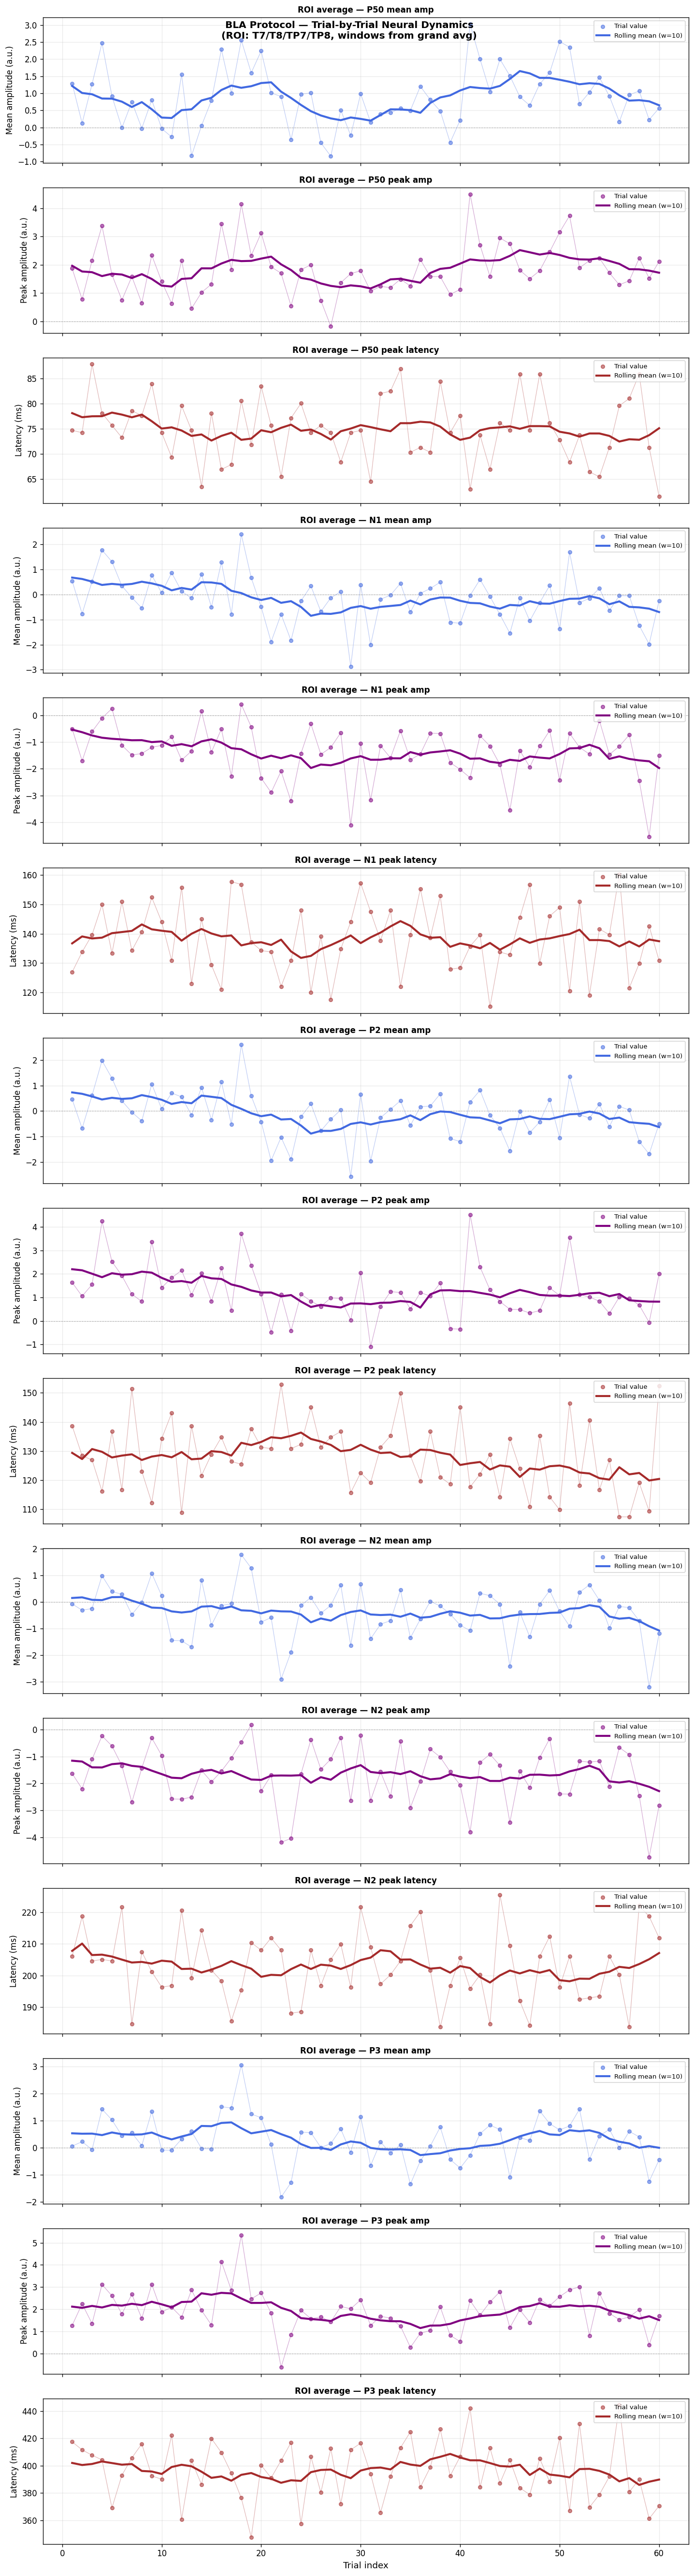

Figure saved: trial_dynamics_BLA_roi_dynamic_windows.png


In [26]:
ROLLING_WINDOW = 10  # trials in the moving average

# =========================
# 1) construct window（res_aud）
# =========================
windows = []
trial_idx = roi_features_df['trial'].values

for comp in component_windows.keys():
    windows.append((
        f'{comp} mean amp',
        roi_features_df[f'{comp}_mean_amp_roi'].values,
        'royalblue',
        'Mean amplitude (a.u.)'
    ))

    windows.append((
        f'{comp} peak amp',
        roi_features_df[f'{comp}_peak_amp_roi'].values,
        'purple',
        'Peak amplitude (a.u.)'
    ))

    windows.append((
        f'{comp} peak latency',
        roi_features_df[f'{comp}_peak_lat_ms_roi'].values,
        'brown',
        'Latency (ms)'
    ))

n_plots = len(windows)

# =========================
# 2) plot
# =========================
fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3*n_plots), sharex=True)

if n_plots == 1:
    axes = [axes]

for ax, (label, values, color, ylab) in zip(axes, windows):

    # --- scatter ---
    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')

    # --- thin line ---
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    # --- rolling mean ---
    s = pd.Series(values)
    rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()

    ax.plot(
        trial_idx,
        rolling,
        color=color,
        linewidth=2.5,
        zorder=3,
        label=f'Rolling mean (w={ROLLING_WINDOW})'
    )

    # --- baseline line（只对 amplitude）
    if "latency" not in label.lower():
        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)

    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(f'ROI average — {label}', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    f'BLA Protocol — Trial-by-Trial Neural Dynamics\n(ROI: T7/T8/TP7/TP8, windows from grand avg)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('trial_dynamics_BLA_roi_dynamic_windows.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: trial_dynamics_BLA_roi_dynamic_windows.png")

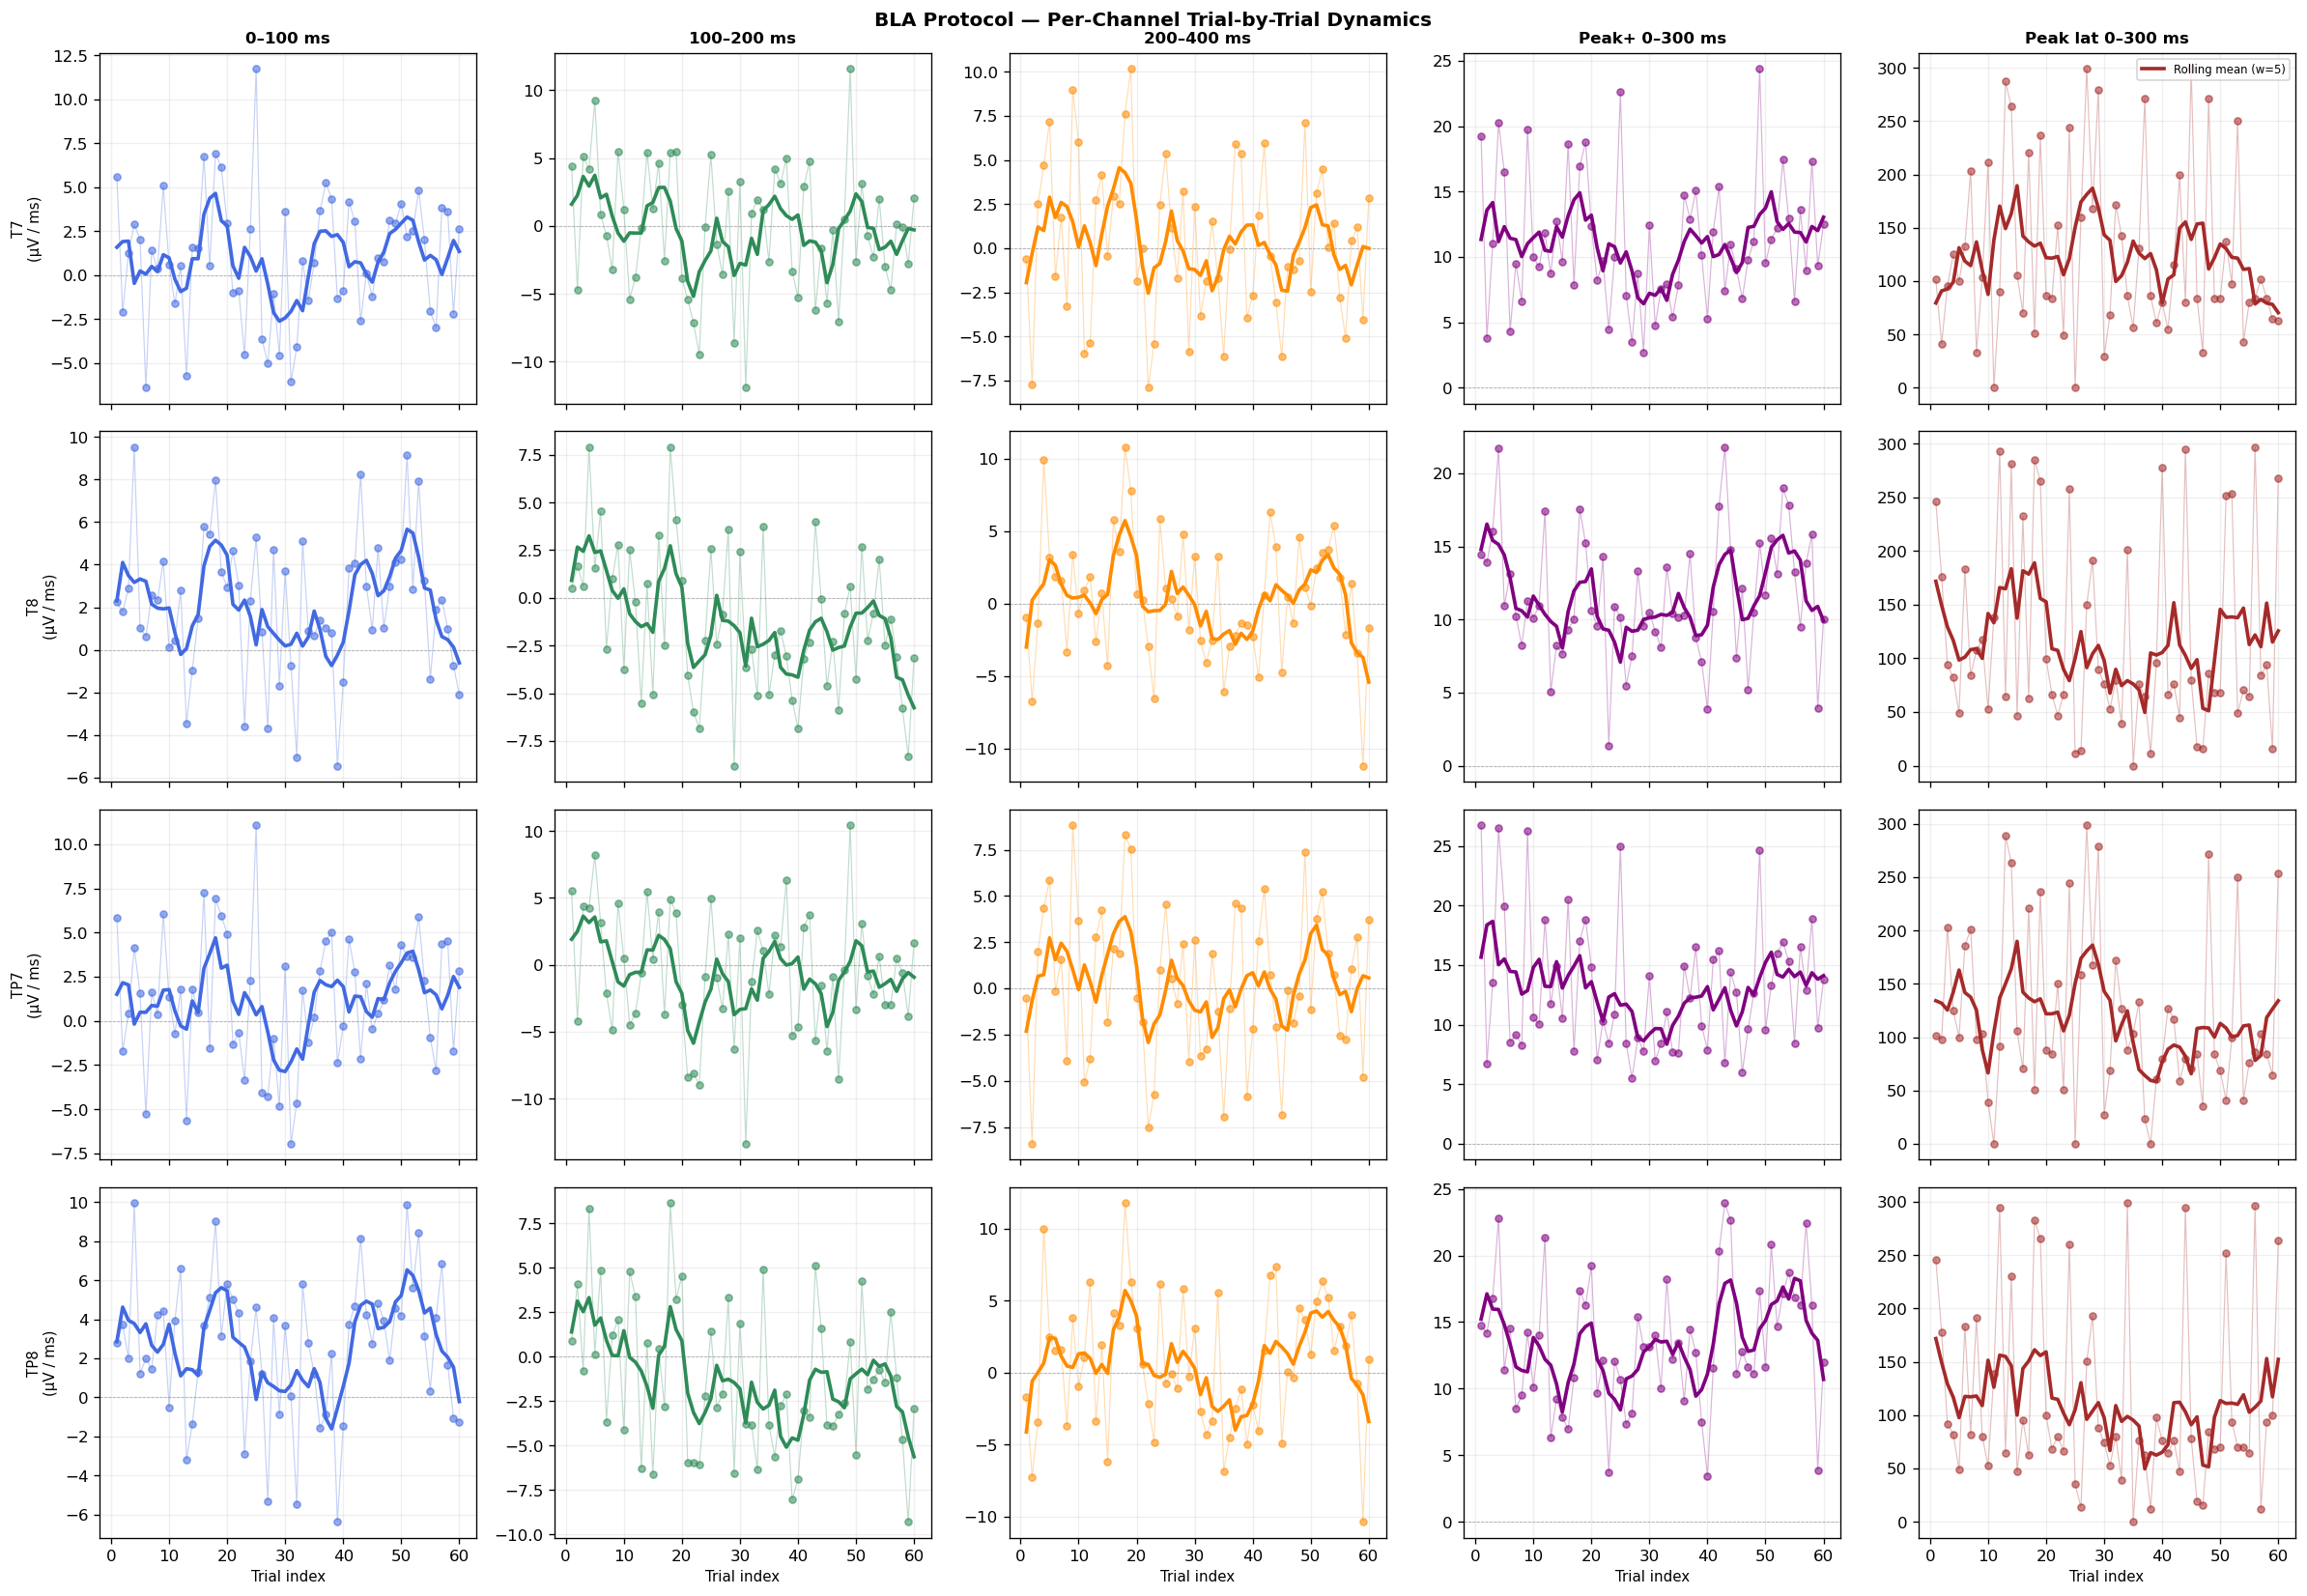

Figure saved: trial_dynamics_BLA_per_channel.png


In [35]:
# --- Per-channel trial-by-trial dynamics ---

feat_arrays = [
    ('0–100 ms',   feat_0_100,   'royalblue'),
    ('100–200 ms', feat_100_200, 'seagreen'),
    ('200–400 ms', feat_200_400, 'darkorange'),
    ('Peak+ 0–300 ms', feat_peak_amp_0_300, 'purple'),
    ('Peak lat 0–300 ms', feat_peak_lat_0_300_ms, 'brown'),
]

fig, axes = plt.subplots(n_channels, 5,
                          figsize=(20, 3.5 * n_channels),
                          sharex=True)

if n_channels == 1:
    axes = axes[np.newaxis, :]

for row, ch in enumerate(ch_names):
    for col, (label, feat_arr, color) in enumerate(feat_arrays):
        ax = axes[row, col]
        values = feat_arr[:, row]

        ax.scatter(trial_idx, values, color=color, s=18, alpha=0.55, zorder=2)
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.30, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.2, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

        if col != 4:
            ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
        ax.grid(True, alpha=0.2)

        if row == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ch}\n(µV / ms)', fontsize=9)
        if row == n_channels - 1:
            ax.set_xlabel('Trial index', fontsize=9)

        if row == 0 and col == 4:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle('BLA Protocol — Per-Channel Trial-by-Trial Dynamics',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_per_channel.png")


## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | varies ("No auditory" removed by `load_eeg_data`) |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Feature windows | 0–100, 100–200, 200–400 ms (mean µV); 0–300 ms (peak µV + peak latency ms) |
| Rolling mean window | 5 trials (centered) |

Next steps:
- Repeat for other protocols (BLT, P1, P2, P3)
- Compare learning curves across protocols
- Statistical tests (e.g., linear regression of feature ~ trial_index)
